# House Price Analysis


## 1. Introduction

Dataset from: https://www.kaggle.com/datasets/prokshitha/home-value-insights

This dataset contains information about 1,000 houses with each row representing a house with various attributes that influence its price. The target variable which we wish to predict is the overall house price, which will depend on the house's various features, such as square footage, number of bedrooms, etc.


pandas DataFrame
      ↓
EDA + plots
      ↓
choose X and y
      ↓
train_test_split()
      ↓
LinearRegression()
      ↓
.fit()
      ↓
.predict()
      ↓
MAE / RMSE / R²
      ↓
plot predictions/residuals
      ↓
interpret results


## 2. Imports
Here, we import the various libraries which we will need in the following analysis.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 3. Load Data
Load the relevant dataseet into a pandas DataFrame.

In [3]:
df = pd.read_csv("../data/house_price_regression_dataset.csv")

## 4. Initial Data Inspection


In [5]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Notable features:**
- Each row is labelled by an index
- Square footage seems to be given in int
- Year built given as an int, rather than a date
- Garage size seems to be the number of cars it fits
- Neighborhood quality on a scale from 1-10
- Only lot size and house price given as floats


### 4.1 Dataset Shape

In [32]:
print(f'df has {df.shape[0]} rows and {df.shape[1]} columns.')

df has 1000 rows and 8 columns.


### 4.2 Data Types

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### 4.3 Missing Values
The above indicates that we have no missing values. However, we check here as this is typically required.

In [24]:
df.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

### 4.4 Duplicate Rows

In [22]:
print(df.duplicated().sum())


0


There are no duplicated rows.

No data cleaning is required for this project. (**NOTE:** make sure the next project has data that requires cleaning.)

## 6. Exploratory Data Analysis

We begin by looking at the table descriiption. This is kept at the top of this section to give basic information that we can look back on.

In [37]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


### 6.1 Target Variable
The target variable for this analysis is the House_Price column, meaning we want to use the various other descriptors to predict this quantity accurately.

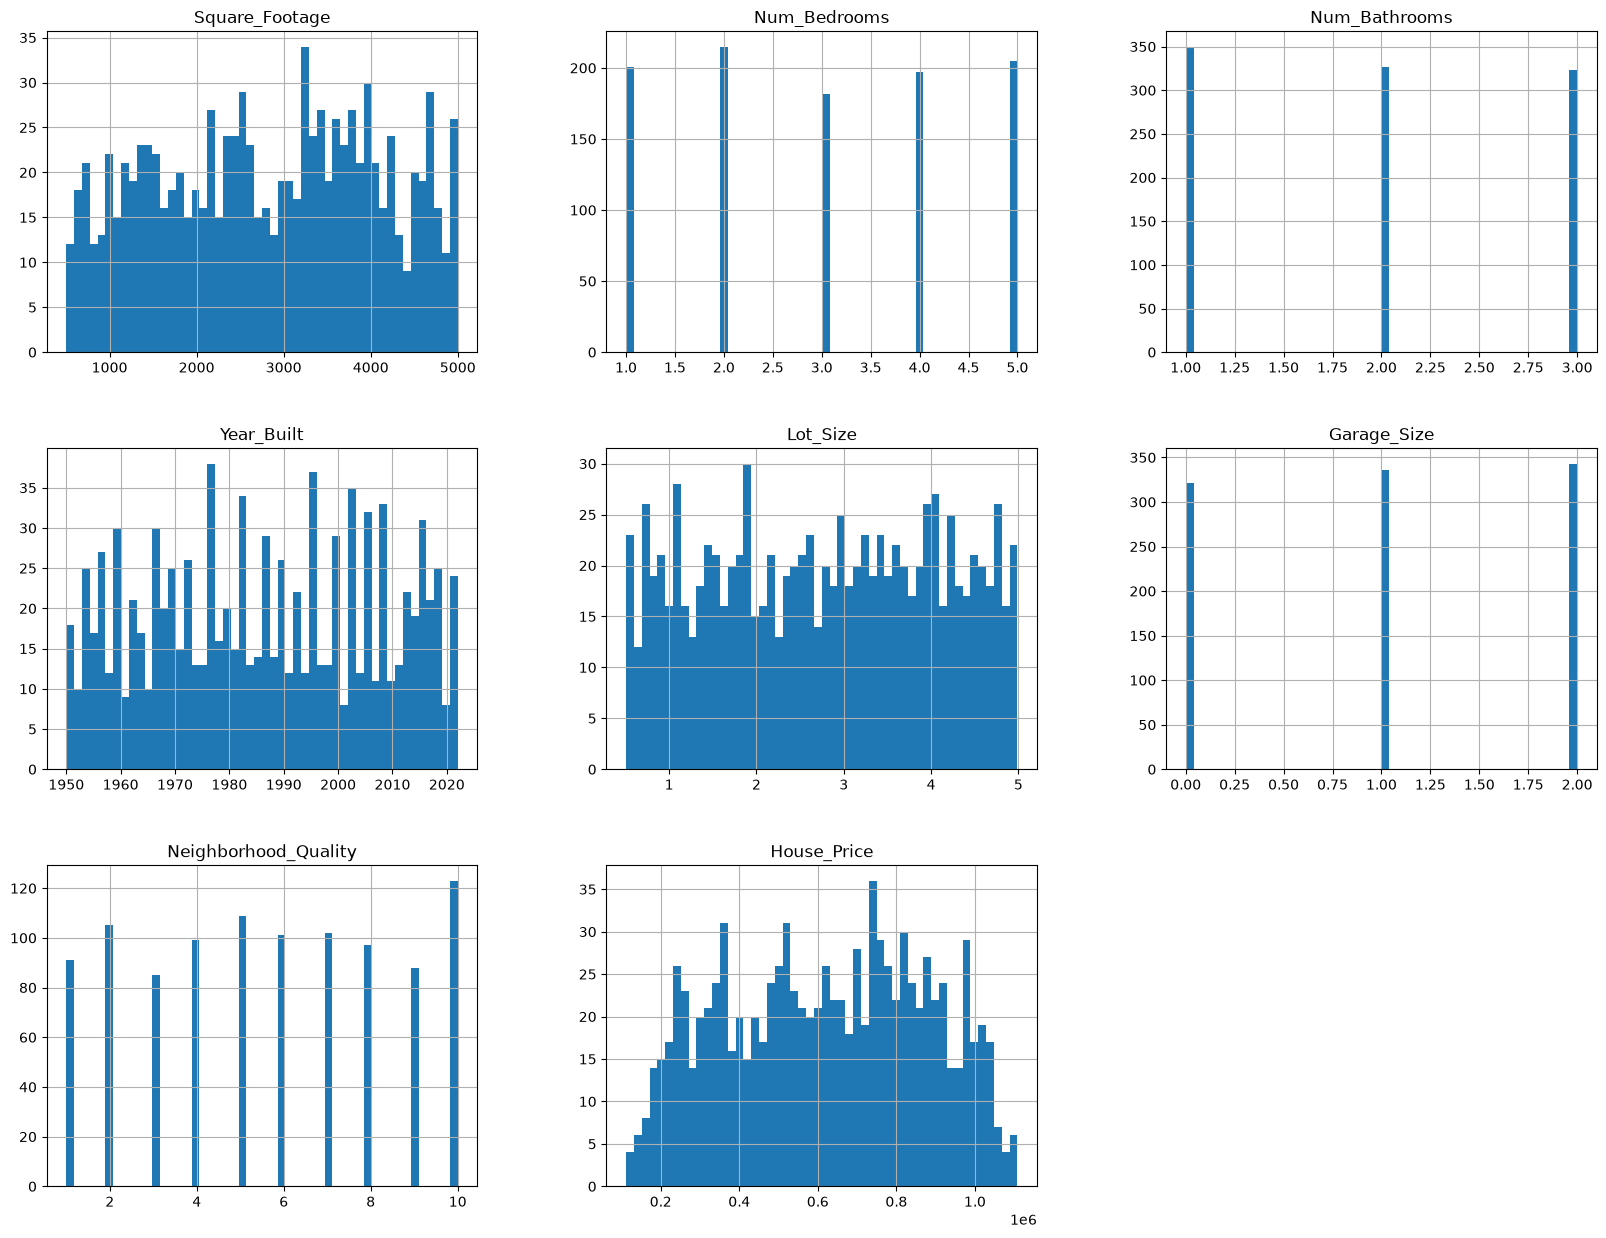

In [7]:
df.hist(bins=50, figsize=(20,15))
plt.show()

House Price description:
count    1.000000e+03
mean     6.188610e+05
std      2.535681e+05
min      1.116269e+05
25%      4.016482e+05
50%      6.282673e+05
75%      8.271413e+05
max      1.108237e+06
Name: House_Price, dtype: float64


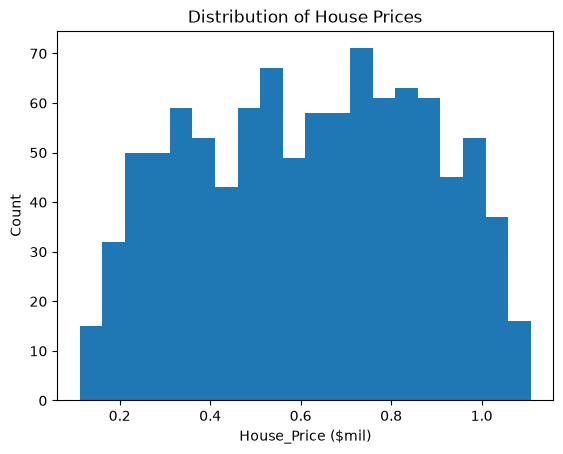

In [61]:
print("House Price description:")
print(df["House_Price"].describe())

plt.hist(df["House_Price"]/1000000,bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("House_Price ($mil)")
plt.ylabel("Count")
plt.show()

House prices seem distributed quite evenly, perhaps with a very slight right skew. Let us look at a box plot of this data.

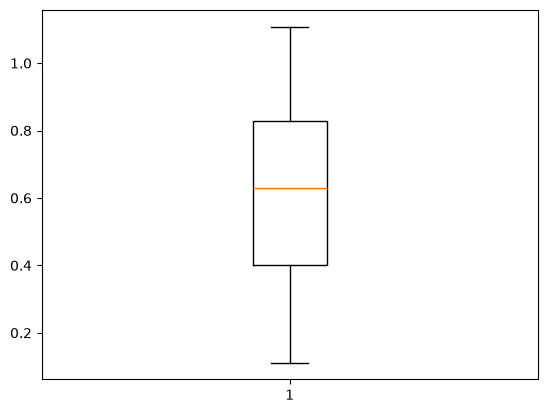

In [72]:
plt.boxplot(df["House_Price"]/1000000)
plt.show()

No visually identifiable skew.

### 6.2 Numerical Features
Here, we go briefly over each variable contained in the data set to check whether there are any outlier values.

#### Square Footage

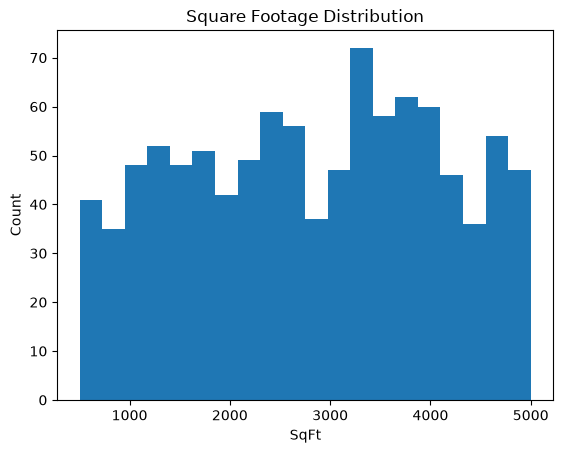

In [76]:
plt.hist(df["Square_Footage"],bins=20)
plt.title("Square Footage Distribution")
plt.xlabel("SqFt")
plt.ylabel("Count")
plt.show()

#### Number of Bedrooms

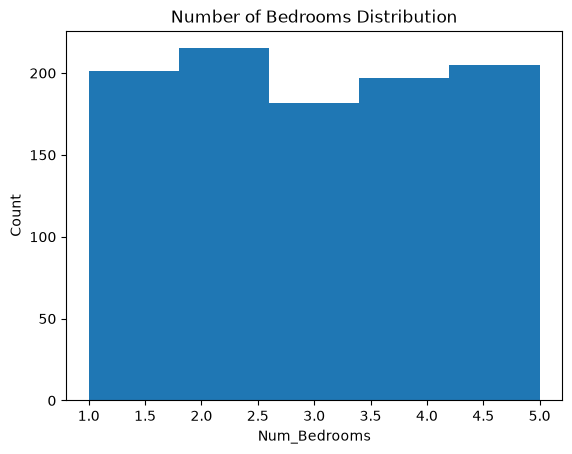

In [88]:
plt.hist(df["Num_Bedrooms"],bins=5)
plt.title("Number of Bedrooms Distribution")
plt.xlabel("Num_Bedrooms")
plt.ylabel("Count")
plt.show()

#### Number of Bathrooms

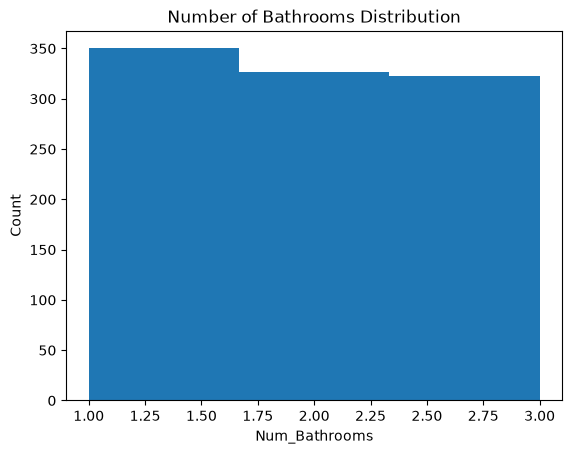

In [90]:
plt.hist(df["Num_Bathrooms"],bins=3)
plt.title("Number of Bathrooms Distribution")
plt.xlabel("Num_Bathrooms")
plt.ylabel("Count")
plt.show()

#### Year Built
Since the min year built was found to be 1950, and the max was 2022, this accounts for (2022-1950)+1 = 73 years in total (+1 since we account for houses built in both 1950 and 2022). We therefore display a box plot using this many bins.

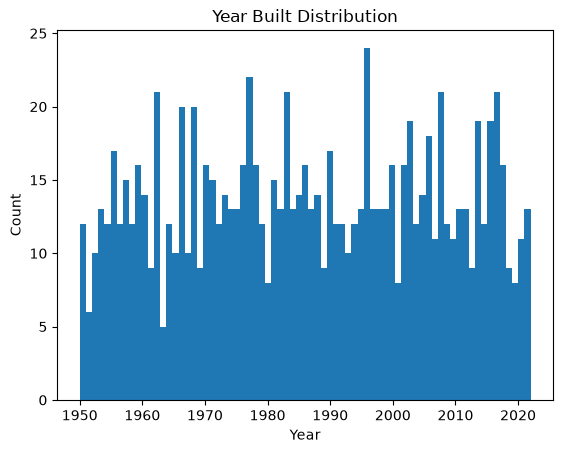

In [75]:
plt.hist(df["Year_Built"],bins=73)
plt.title("Year Built Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#### Lot Size

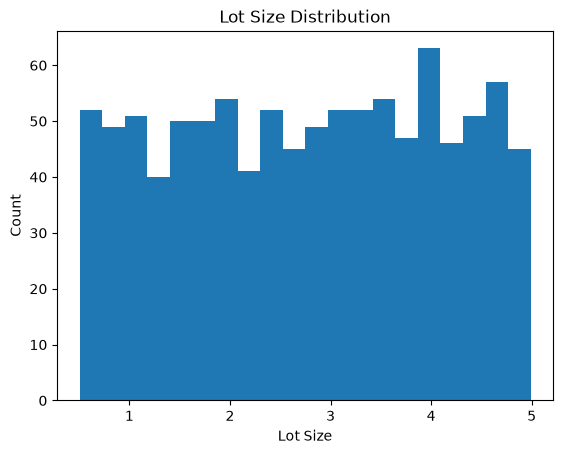

In [68]:
plt.hist(df["Lot_Size"],bins=20)
plt.title("Lot Size Distribution")
plt.xlabel("Lot Size")
plt.ylabel("Count")
plt.show()

#### Garage Size
Note that there are only three distinct values, 0, 1, or 2, describing the number of car spaces available in the garage.

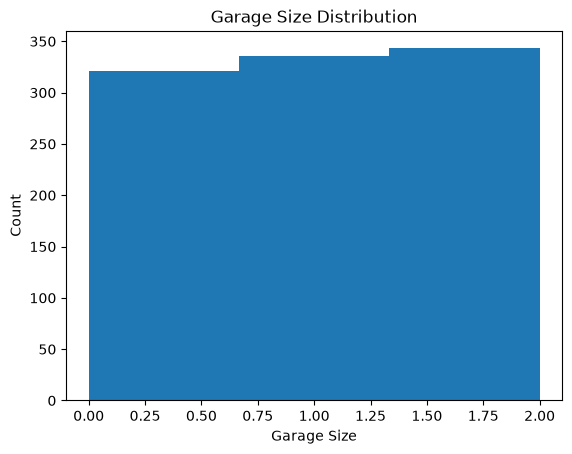

In [79]:
plt.hist(df["Garage_Size"],bins=3)
plt.title("Garage Size Distribution")
plt.xlabel("Garage Size")
plt.ylabel("Count")
plt.show()

#### Neighborhood Quality

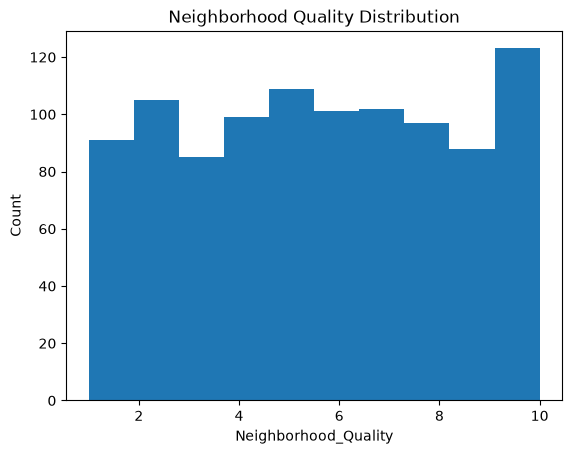

In [93]:
plt.hist(df["Neighborhood_Quality"],bins=10)
plt.title("Neighborhood Quality Distribution")
plt.xlabel("Neighborhood_Quality")
plt.ylabel("Count")
plt.show()

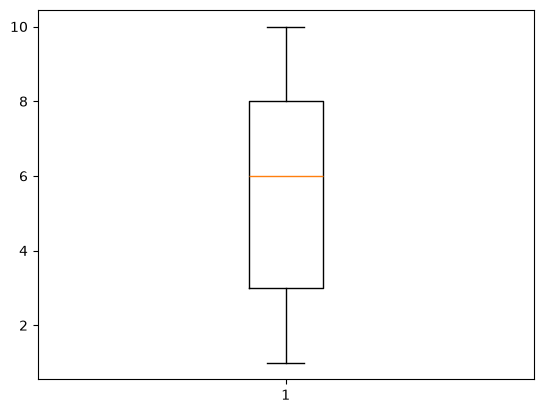

In [94]:
plt.boxplot(df["Neighborhood_Quality"])
plt.show()

Neighborhood quality seems to skew slightly higher.

**Summary:**: Overall, each variable seems to have approximatly even distribution.

### 6.4 Relationships Between Variables
Here, we are looking for the predictors which give the strongest correlation with the target variable. This is only a preliminary analysis, so we will just perform an inspection at this point.

In [96]:
df.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.852274
1,4272,3,3,2016,4.753014,1,6,985260.854490


#### Square Footage

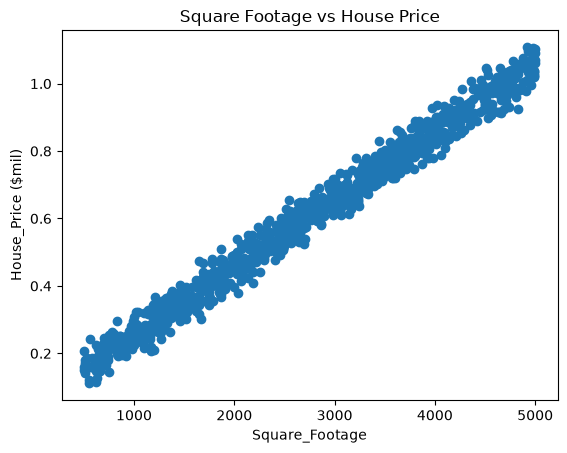

In [101]:
plt.scatter(df["Square_Footage"],df["House_Price"]/1e6)
plt.title("Square Footage vs House Price")
plt.xlabel("Square_Footage")
plt.ylabel("House_Price ($mil)")
plt.show()

Very strong linear relationship between these variable. Makes a lot of sense, though it is perhaps surprising that the house price is *linear* with the square footage, and not higher order.

#### Number of Bedrooms

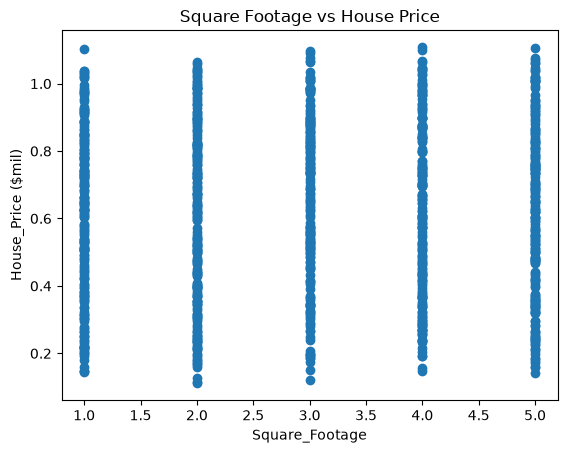

In [102]:
plt.scatter(df["Num_Bedrooms"],df["House_Price"]/1e6)
plt.title("Number of Bedrooms vs House Price")
plt.xlabel("Num_Bedrooms")
plt.ylabel("House_Price ($mil)")
plt.show()

Hard to see any sort of strong relationship between number of bedrooms and the house price. Let's use a strip plot to look at this with a bit more clarity.

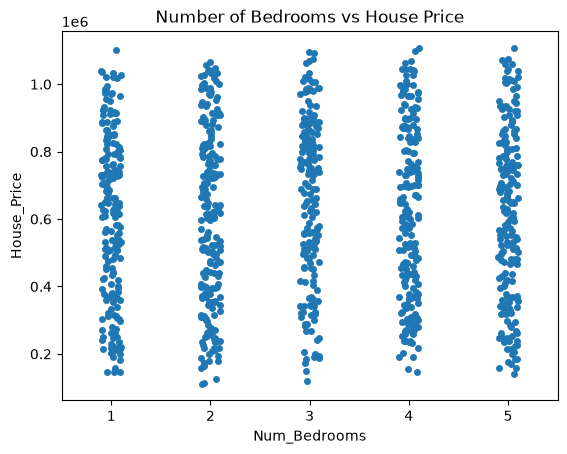

In [113]:
sns.stripplot(data=df, 
              x="Num_Bedrooms",
              y="House_Price",
              jitter=True)
plt.title("Number of Bedrooms vs House Price")
plt.xlabel("Num_Bedrooms")
plt.ylabel("House_Price")
plt.show()

Still hard to see any sort of relationship. Though it looks like there may be a small outlier in Num_Bedrooms=1, with one house being above the rest (doesn't looks dramatic though).

#### Number of Bathrooms

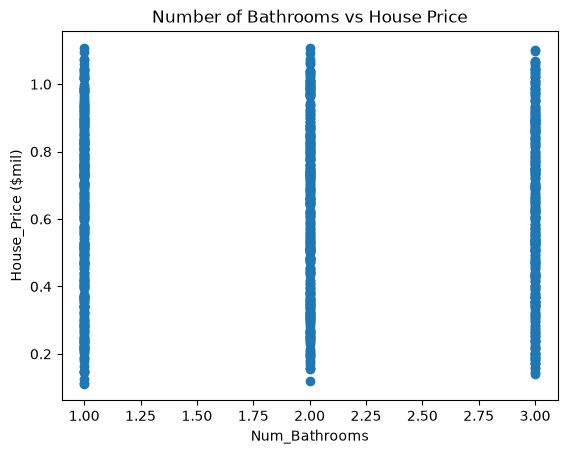

In [114]:
plt.scatter(df["Num_Bathrooms"],df["House_Price"]/1e6)
plt.title("Number of Bathrooms vs House Price")
plt.xlabel("Num_Bathrooms")
plt.ylabel("House_Price ($mil)")
plt.show()

Again very little to see, though perhaps a slight negative correlation? Let's use a strip plot again to look closer.

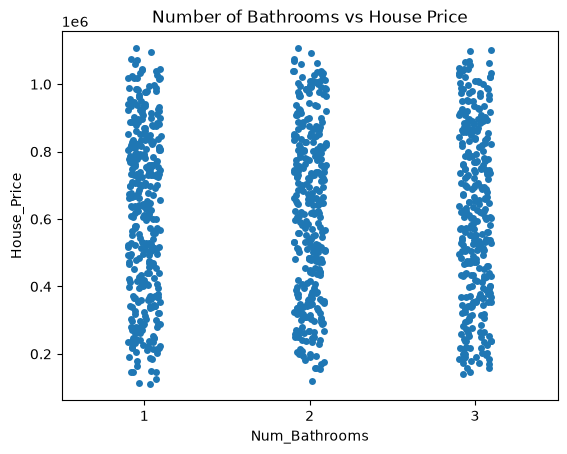

In [115]:
sns.stripplot(data=df, 
              x="Num_Bathrooms",
              y="House_Price",
              jitter=True)
plt.title("Number of Bathrooms vs House Price")
plt.xlabel("Num_Bathrooms")
plt.ylabel("House_Price")
plt.show()

Still not much to see, likely a very weak correlation.

#### Year Built

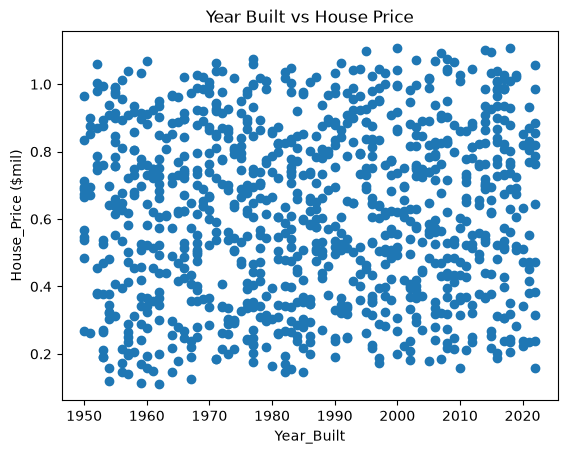

In [116]:
plt.scatter(df["Year_Built"],df["House_Price"]/1e6)
plt.title("Year Built vs House Price")
plt.xlabel("Year_Built")
plt.ylabel("House_Price ($mil)")
plt.show()

Impossible to see any sort of dependence on year built. Assuming that these are the current listed prices, this makes a lot of sense as the overall house price will have generally increased regardless of year built. Also makes sense that this isn't a strong correlation since there will be other more important factors.

#### Lot Size

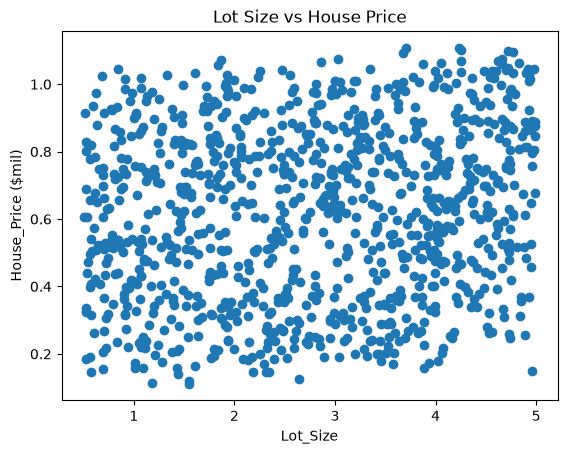

In [117]:
plt.scatter(df["Lot_Size"],df["House_Price"]/1e6)
plt.title("Lot Size vs House Price")
plt.xlabel("Lot_Size")
plt.ylabel("House_Price ($mil)")
plt.show()

Surprisingly weak positive correlation.

#### Garage Size

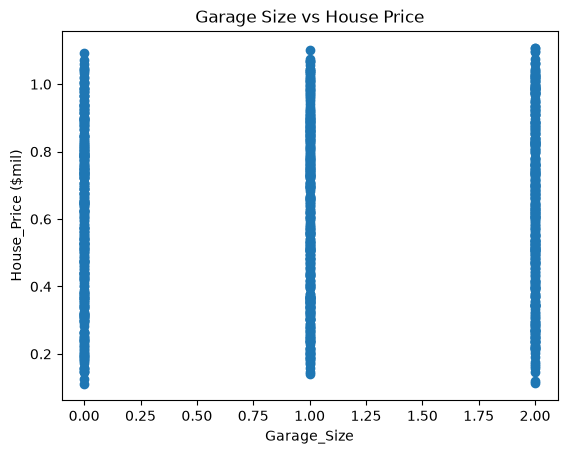

In [118]:
plt.scatter(df["Garage_Size"],df["House_Price"]/1e6)
plt.title("Garage Size vs House Price")
plt.xlabel("Garage_Size")
plt.ylabel("House_Price ($mil)")
plt.show()

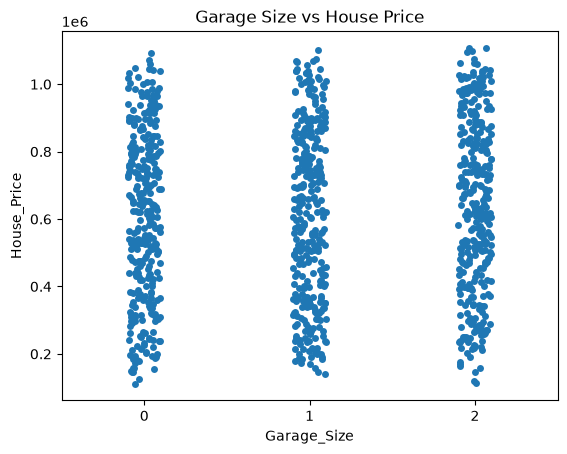

In [120]:
sns.stripplot(data=df, 
              x="Garage_Size",
              y="House_Price",
              jitter=True)
plt.title("Garage Size vs House Price")
plt.xlabel("Garage_Size")
plt.ylabel("House_Price")
plt.show()

Very weak positive correlation, if any.

#### Neighborhood Quality

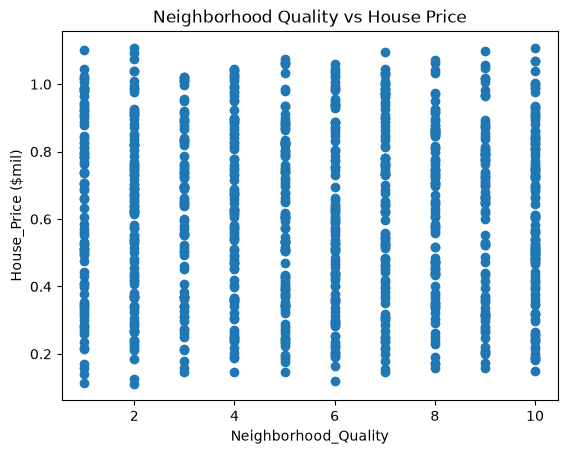

In [121]:
plt.scatter(df["Neighborhood_Quality"],df["House_Price"]/1e6)
plt.title("Neighborhood Quality vs House Price")
plt.xlabel("Neighborhood_Quality")
plt.ylabel("House_Price ($mil)")
plt.show()

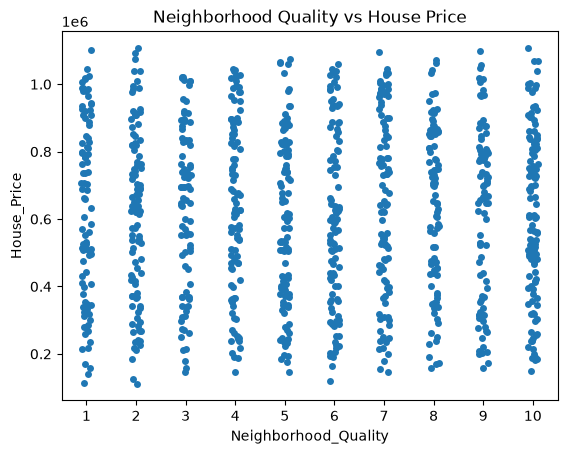

In [122]:
sns.stripplot(data=df, 
              x="Neighborhood_Quality",
              y="House_Price",
              jitter=True)
plt.title("Neighborhood Quality vs House Price")
plt.xlabel("Neighborhood_Quality")
plt.ylabel("House_Price")
plt.show()

Again, a surprisingly weak correlation.

### Correlations
Since every predictor is numeric, we can directly find the relevant correlations for house price of each variable.

In [130]:
df.corr()["House_Price"].sort_values(ascending=False)

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64

Inspecting the above, this confirms that, out of all the predictors, **square footage** has by far the strongest correlation with house price, being nearly exactly 1. The second highest is lot size, which we identified as having rather weak correlation, which is true.

All other predictors have extremely weak correlation with house price, which is rather surprising. Notably, neighborhood quality has *negative* correlation with house prices, which at first glance does not make a lot of sense. Indeed, from our above univariate analysis of neighborhood quality we observed that it is almost uniform, meaning it contains almost no relevant information. It is also surprising the number of 1 values in neighborhood quality. This quantity looks almost randomly generated (which it probably is).

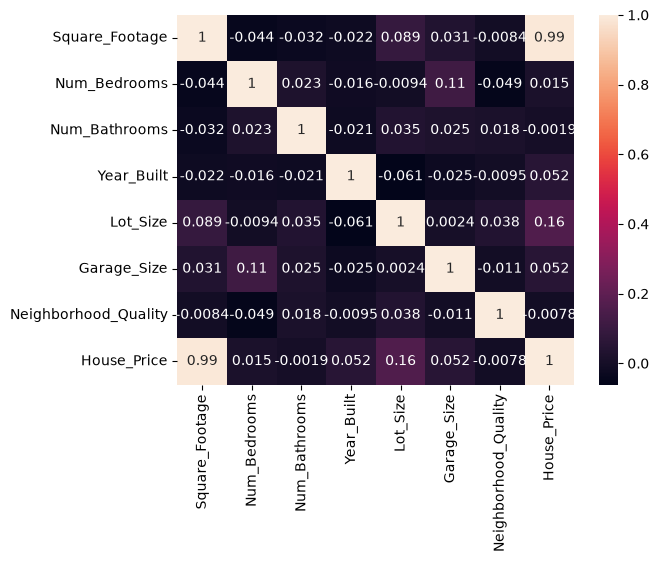

In [132]:
correlations = df.corr()

sns.heatmap(
    correlations,
    annot=True
)
plt.show()

## 7. Modelling

As only one feature is highly correlated with house price, we begin by making a baseline model that uses only this predictor to estimate the house prices.

### 7.1 Train/Test Split
The train/test split divides our data into two distinct subsets: one for training the model, and another for evaluating its performance on unseen data. A typical rule of thumb is 80% of the data should be used in training, with the remaining 20% used for testing.

To do this, we use train_test_split from sklearn.model_selection. This divides our data into features (X) and responses (y). In particular, our DataFrame is divided into X_train, X_test, y_train, and y_test, where the split depends on the test_size parameter (defaults to 0.25, i.e. to 25% of the total data set). We will modify this to 0.2, to follow the rule of thumb mentioned above.

To have more control over the data, train_test_split can take a number of other parameters:
- random_state: controls how the data is shuffled before the split is implemented. This can be chosen explicitly for repeatable outputs by passing an int.
- shuffle: controls whether or not the data should be shuffled before splitting, and defaults to True. This is generally good to have on, in particular for any dataset that possesses some kind of order already (e.g. the houses are listed by date built).

In [194]:
# First, we limit our data to include only the strongest predictor:
X = df[["Square_Footage"]]
y = df[["House_Price"]]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

### 7.2 Baseline Model
Next, we build a linear regression model from sklearn.linear_model, which we imported at the start of this notebook as LinearRegression. We check the default evaluation metric of the fit by using .score(), which returns the $R^2$ coefficient for the test dataset (note that for classification models, this score returns the mean accuracy of the model's predictions).

We additionally return:
- Mean absolute error
- Root mean squared error
- $R^2$ error (already given in the score)

The score is 0.9840254582428262
Mean absolute error: 26103.079395860535
Root mean squared error: 1030859294.0952646
R squared score: 0.9840254582428262


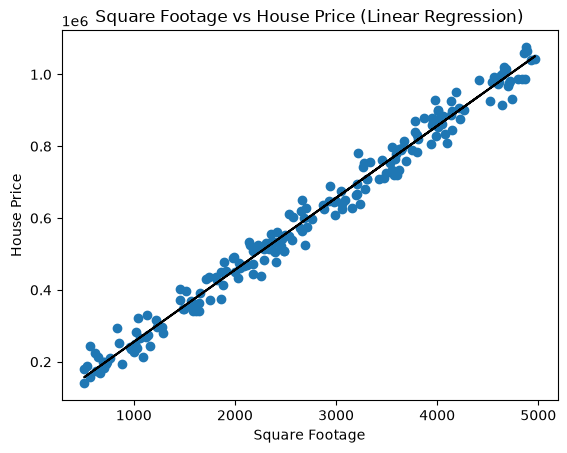

In [196]:
model = LinearRegression()

model.fit(X_train, y_train)

print(f"The score is {model.score(X_test, y_test)}")

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"Root mean squared error: {rmse}")
print(f"R squared score: {r2}")

y_pred = model.predict(X_test)
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='k')
plt.title("Square Footage vs House Price (Linear Regression)")
plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.show()

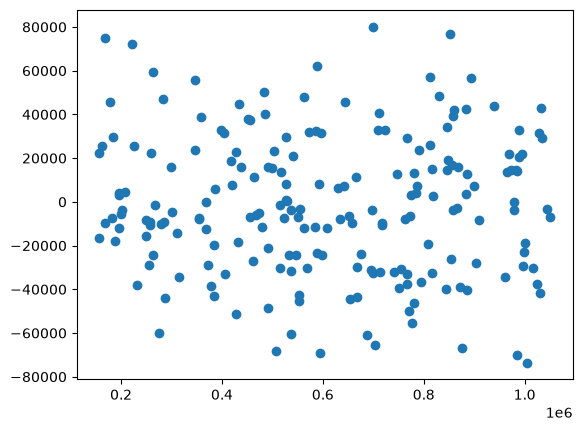

In [198]:
residuals = y_test - y_pred
plt.scatter(y_pred,residuals)
plt.show()

### 7.3 Multivariate Analysis

In [190]:
df_all_predictors = df.drop("House_Price", axis=1)
X = df_all_predictors
y = df[["House_Price"]]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [191]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean absolute error: {mae}")
print(f"Root mean squared error: {rmse}")
print(f"R squared score: {r2}")


Mean absolute error: 7991.534647052787
Root mean squared error: 101791880.52912575
R squared score: 0.9983449028586162


Including all predictors improved the $R^2$ score from 0.984 to 0.998, which is not a substantial improvement (note that there was not much room for improvement, so this mutlivariate analysis was perhaps not worth the time).

### 7.4 Model 2

## 9. Model Evaluation


## 10. Conclusions

